# Basic Data Audit, Cleaning & Curation

<!--<badge>--><a href="https://colab.research.google.com/github/kuennethgroup/ml_in_ms_st26/blob/main/03_ex/data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->

In this notebook we work with a small synthetic **materials science dataset** containing mechanical and thermal properties of several alloys.  
The dataset has been deliberately "dirtied" with the kinds of problems you will encounter in real research data.  
Your job is to find, understand, and fix them.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

Run the cell below to create the dirty dataset.  
It contains the following columns:

| Column | Description | Expected type | Physical constraint |
|--------|-------------|---------------|---------------------|
| `material` | Alloy name | string | — |
| `youngs_modulus_GPa` | Young's modulus (GPa) | float | > 0 |
| `yield_strength_MPa` | Yield strength (MPa) | float | > 0 |
| `density_g_cm3` | Density (g/cm³) | float | > 0 |
| `melting_point_K` | Melting point (Kelvin) | float | > 0 |
| `source_lab` | Laboratory that measured the data | string | — |

In [2]:
df = pd.read_csv("materials_data.csv")
df

,material,youngs_modulus_GPa,yield_strength_MPa,density_g_cm3,melting_point_K,source_lab
0,Ti-6Al-4V,114,'880',4.43,1933,Lab A
1,Ti-6Al-4V,115,875,4.43,1933,Lab B
2,316L Steel,193,310,7.99,1673,Lab A
3,316L Steel,195,305,8.0,1673,Lab C
4,AlSi10Mg,70,250,2.67,873,Lab A
...,...,...,...,...,...,...
169,17-4 PH,198,1000,7.78,1698,Lab C
170,17-4 PH,196,998,7.78,1698,Lab D
171,17-4 PH,197,1003,7.78,1698,Lab E
172,17-4 PH,198,999,7.78,16098,Lab A


---
## Part 1 — Data Audit

Before cleaning anything, **audit** the data: understand what types and values are present, and flag suspicious entries.

### 1a) Check data types

Verify the dtype of each column.  
A numeric column reported as `object` is a red flag — it likely contains strings mixed with numbers.

**Exercise**  
- Run `df.dtypes` and `df.info()`.  
- Which columns have an unexpected `object` dtype?  
- Why is this a problem for a calculation like `E / density` (specific stiffness)?

In [3]:
print(df.dtypes)
print()
df.info()

material              object
youngs_modulus_GPa    object
yield_strength_MPa    object
density_g_cm3         object
melting_point_K        int64
source_lab            object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   material            174 non-null    object
 1   youngs_modulus_GPa  173 non-null    object
 2   yield_strength_MPa  172 non-null    object
 3   density_g_cm3       174 non-null    object
 4   melting_point_K     174 non-null    int64 
 5   source_lab          174 non-null    object
dtypes: int64(1), object(5)
memory usage: 8.3+ KB


In [4]:
# TODO: try to compute specific stiffness and observe the error
# Why does this error occur?
# df["specific_stiffness"] = df["youngs_modulus_GPa"] / df["density_g_cm3"]

### 1b) Value ranges — descriptive statistics

Use descriptive statistics to spot physically impossible values.

**Exercise**  
- Call `df.describe()`.  
- Look at `min` and `max` for each numeric column.  
- Which values are physically impossible?  
  - Hint: Can Young's modulus be negative? Can temperature be below 0 K?

In [5]:
# Note that string columns are excluded automatically
df.describe()

,melting_point_K
count,174.000000
mean,1623.166667
std,1612.155485
min,-1698.000000
25%,908.000000
50%,1623.000000
75%,1691.750000
max,16098.000000


In [6]:
# Print rows where melting_point_K <= 0 or youngs_modulus_GPa <= 0
# First we need to coerce the mixed columns to numeric
df_num = df.copy()
df_num["youngs_modulus_GPa"] = pd.to_numeric(
    df_num["youngs_modulus_GPa"], errors="coerce"
)
df_num["yield_strength_MPa"] = pd.to_numeric(
    df_num["yield_strength_MPa"], errors="coerce"
)
df_num["density_g_cm3"] = pd.to_numeric(df_num["density_g_cm3"], errors="coerce")

print("Rows with non-positive Young's modulus:")
display(df_num[df_num["youngs_modulus_GPa"] <= 0])

print("Rows with non-positive melting point:")
display(df_num[df_num["melting_point_K"] <= 0])

Rows with non-positive Young's modulus:


,material,youngs_modulus_GPa,yield_strength_MPa,density_g_cm3,melting_point_K,source_lab
19,AlSi10Mg,-70.0,248.0,2.68,-500,Lab B
44,Al 7075,-72.0,498.0,-2.81,908,Lab B


Rows with non-positive melting point:


,material,youngs_modulus_GPa,yield_strength_MPa,density_g_cm3,melting_point_K,source_lab
19,AlSi10Mg,-70.0,248.0,2.68,-500,Lab B
167,17-4 PH,196.0,995.0,7.78,-1698,Lab E


### 1c) Correlations — scatter plot matrix

Plot all numeric columns against each other to see correlations and spot outliers visually.

**Exercise**  
- Use `seaborn.pairplot` on the numeric columns. Color the points by `material`.  
- Can you spot the outlier in `youngs_modulus_GPa` visually?  
- What do you notice about the density of `AlSi10Mg` vs. the steels and alloys?

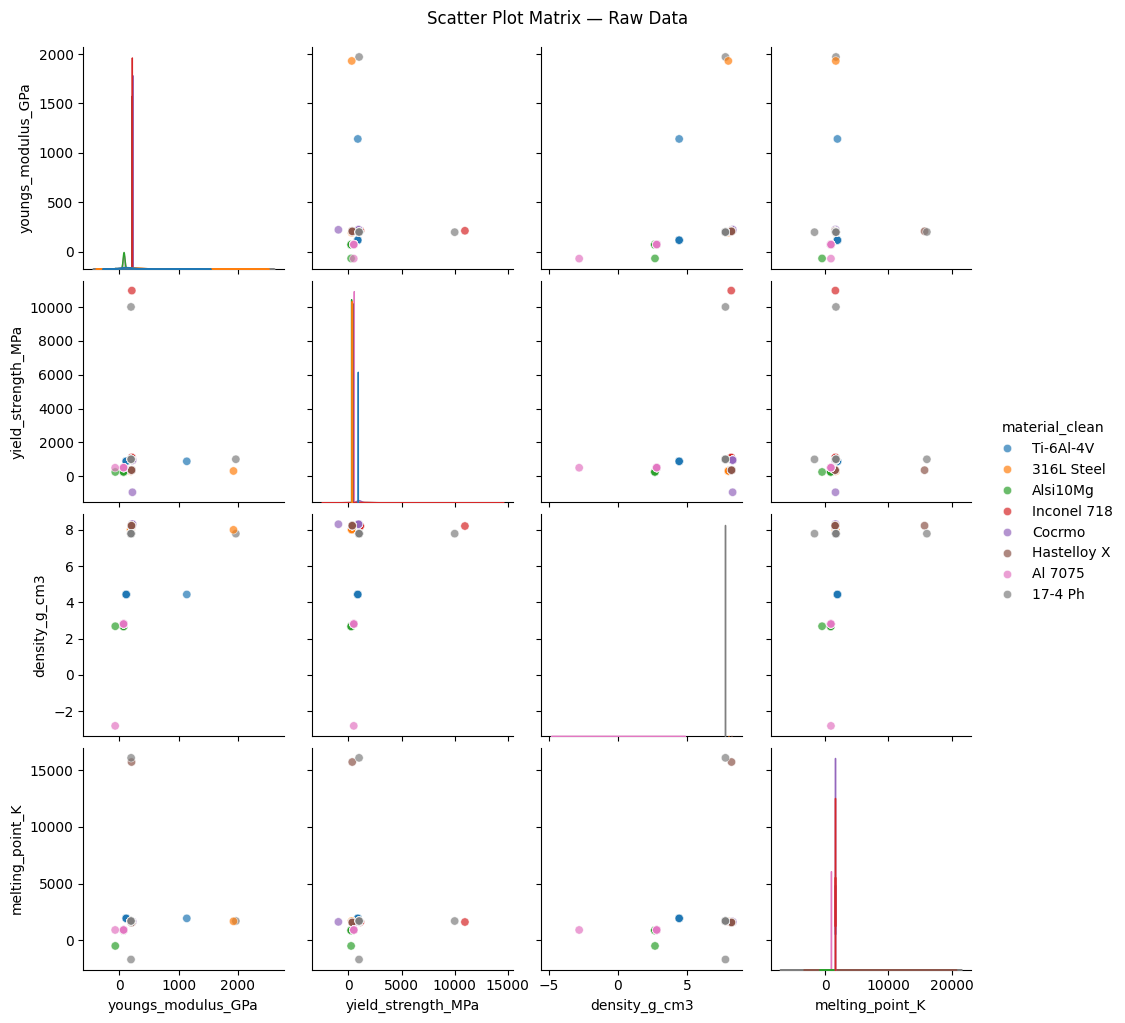

In [7]:
# TODO: create pairplot of numeric columns colored by material
numeric_cols = [
    "youngs_modulus_GPa",
    "yield_strength_MPa",
    "density_g_cm3",
    "melting_point_K",
]

df_plot = df_num.copy()
# Clean material names for plotting (strip whitespace, unify case)
df_plot["material_clean"] = df_plot["material"].str.strip().str.title()

sns.pairplot(
    df_plot[numeric_cols + ["material_clean"]].dropna(),
    hue="material_clean",
    plot_kws={"alpha": 0.7},
)
plt.suptitle("Scatter Plot Matrix — Raw Data", y=1.02)
plt.show()

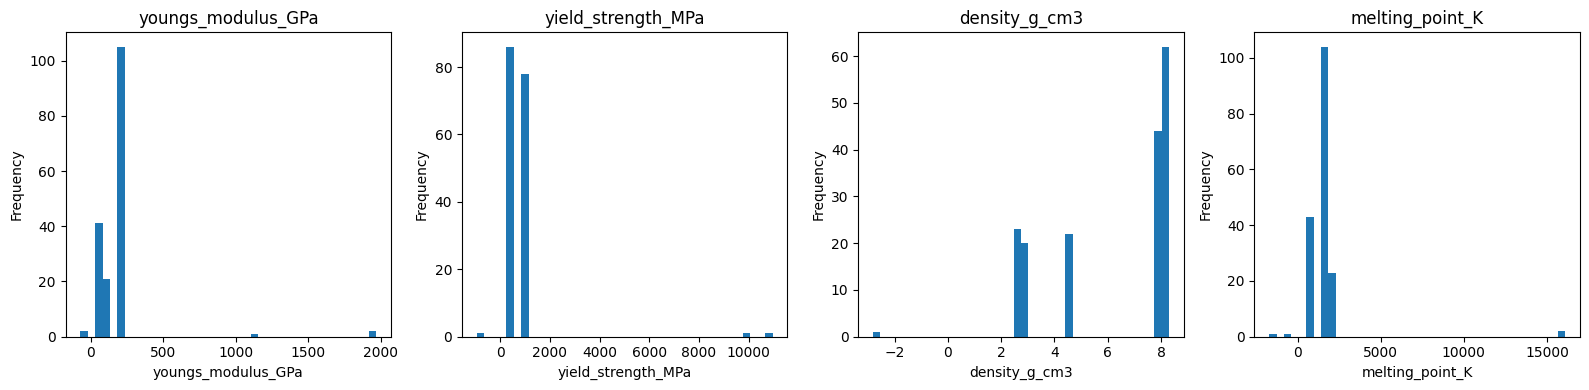

In [8]:
# TODO: additionally plot density distributions for each numeric column
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    df_plot[col].dropna().plot(kind="hist", bins=40, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

---
## Part 2 — Cleaning Strategy

Now that you have found the issues, fix them systematically.

We split the strategy into **by-hand** (domain-knowledge-driven) and **data-driven** steps.

### 2a) By-hand cleaning

**Exercise**  
1. Convert `youngs_modulus_GPa` and `yield_strength_MPa` to numeric types (use `pd.to_numeric`).  
2. Strip leading/trailing whitespace from the `material` column.  
3. Lowercase-then-title-case all material names so `'alsi10mg'` becomes `'Alsi10Mg'`  
   (or fix it explicitly to `'AlSi10Mg'`).  
4. Drop rows where `youngs_modulus_GPa <= 0` or `melting_point_K <= 0` — these are physically impossible.  
5. Verify with `df.describe()` that all `min` values are now positive.

In [9]:
df_clean = df.copy()

# --- Step 1: fix dtypes ---
df_clean["youngs_modulus_GPa"] = pd.to_numeric(
    df_clean["youngs_modulus_GPa"], errors="coerce"
)
df_clean["yield_strength_MPa"] = pd.to_numeric(
    df_clean["yield_strength_MPa"], errors="coerce"
)

df_clean["density_g_cm3"] = pd.to_numeric(df_clean["density_g_cm3"], errors="coerce")

# --- Step 2 & 3: fix string issues ---
df_clean["material"] = df_clean["material"].str.strip()

# Map known bad names to canonical names
name_map = {"alsi10mg": "AlSi10Mg"}
df_clean["material"] = df_clean["material"].replace(name_map)

print("Unique material names before cleaning:", df["material"].unique())
print("Unique material names after cleaning:", df_clean["material"].unique())

Unique material names before cleaning: ['Ti-6Al-4V' '316L Steel' 'AlSi10Mg' 'Inconel 718' 'CoCrMo' ' Ti-6Al-4V'
 'alsi10mg' '316l steel' 'Hastelloy X' ' Hastelloy X' 'Al 7075' '17-4 PH'
 'INCONEL 718' 'hastelloy x' '316L STEEL' 'inconel 718' 'HASTELLOY X'
 '17-4 ph']
Unique material names after cleaning: ['Ti-6Al-4V' '316L Steel' 'AlSi10Mg' 'Inconel 718' 'CoCrMo' '316l steel'
 'Hastelloy X' 'Al 7075' '17-4 PH' 'INCONEL 718' 'hastelloy x'
 '316L STEEL' 'inconel 718' 'HASTELLOY X' '17-4 ph']


In [10]:
# --- Step 4: remove physically impossible values ---
before = len(df_clean)
df_clean = df_clean[df_clean["youngs_modulus_GPa"] > 0]
df_clean = df_clean[df_clean["melting_point_K"] > 0]
after = len(df_clean)
print(f"Removed {before - after} row(s) with physically impossible values.")

df_clean.describe()

Removed 5 row(s) with physically impossible values.


,youngs_modulus_GPa,yield_strength_MPa,density_g_cm3,melting_point_K
count,169.000000,162.000000,168.000000,169.000000
mean,187.597633,764.500000,6.308274,1662.011834
std,215.921318,1146.445553,2.373559,1604.908613
min,68.000000,-950.000000,2.670000,870.000000
25%,113.000000,311.000000,4.430000,1573.000000
50%,196.000000,504.000000,7.990000,1623.000000
75%,209.000000,953.750000,8.202500,1698.000000
max,1970.000000,10970.000000,8.300000,16098.000000


### 2b) Remove outliers (data-driven)

Use the **IQR (interquartile range)** method to flag statistical outliers per material group. The IQR method identifies outliers by flagging data points that fall outside the lower and upper bounds:
- Lower bound: Q1 − 1.5·IQR
- Upper bound: Q3 + 1.5·IQR

**Exercise**  
- For `youngs_modulus_GPa`, compute Q1, Q3, and IQR *per material*.  
- Flag rows where the value falls outside `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`.  
- Print the flagged rows and decide whether to drop them.  
- Visualise the result with a box plot before and after.

In [11]:
def iqr_outlier_mask(series):
    """Return a boolean mask: True where value is an IQR outlier."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)


outlier_mask = df_clean.groupby("material")["youngs_modulus_GPa"].transform(
    iqr_outlier_mask
)
print("Outlier rows:")
print(df_clean[outlier_mask])

Outlier rows:
      material  youngs_modulus_GPa  yield_strength_MPa  density_g_cm3  \
17   Ti-6Al-4V              1140.0               880.0           4.43   
48     17-4 PH              1970.0              1002.0           7.78   
93  316L Steel              1930.0               307.0           7.99   

    melting_point_K source_lab  
17             1933      Lab B  
48             1698      Lab A  
93             1673      Lab E  


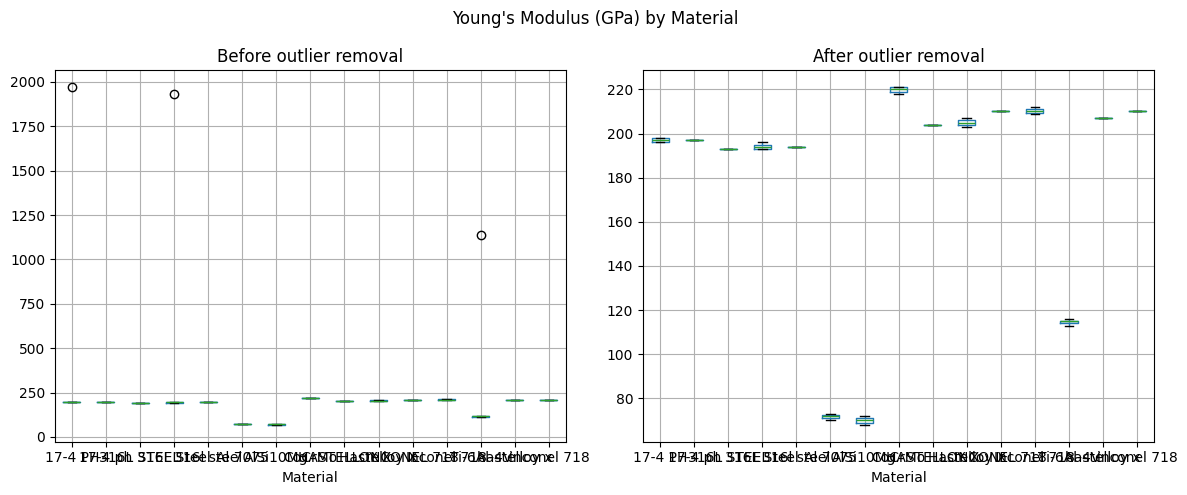

Rows remaining: 166


In [12]:
# Visualise before / after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_clean.boxplot(column="youngs_modulus_GPa", by="material", ax=axes[0])
axes[0].set_title("Before outlier removal")
axes[0].set_xlabel("Material")

df_no_outliers = df_clean[~outlier_mask].reset_index(drop=True)
df_no_outliers.boxplot(column="youngs_modulus_GPa", by="material", ax=axes[1])
axes[1].set_title("After outlier removal")
axes[1].set_xlabel("Material")

plt.suptitle("Young's Modulus (GPa) by Material")
plt.tight_layout()
plt.show()

df_clean = df_no_outliers
print(f"Rows remaining: {len(df_clean)}")

### 2c) Find duplicates

**Exercise**  
- Use `df.duplicated()` to find fully duplicated rows.  
- Then check for rows that share the same `material` and `source_lab` but have suspiciously close property values — these could be accidental double entries.  
- Drop exact duplicates.

In [13]:
# Exact duplicates
dupes = df_clean[df_clean.duplicated(keep=False)]
print(f"Exact duplicate rows: {len(dupes)}")
display(dupes)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Rows after dropping exact duplicates: {len(df_clean)}")

Exact duplicate rows: 7


,material,youngs_modulus_GPa,yield_strength_MPa,density_g_cm3,melting_point_K,source_lab
4,AlSi10Mg,70.0,250.0,2.67,873,Lab A
37,Al 7075,72.0,503.0,2.81,908,Lab A
39,Al 7075,73.0,505.0,2.81,908,Lab C
40,Al 7075,72.0,503.0,2.81,908,Lab A
95,AlSi10Mg,70.0,250.0,2.67,873,Lab A
146,Al 7075,72.0,503.0,2.81,908,Lab A
148,Al 7075,73.0,505.0,2.81,908,Lab C


Rows after dropping exact duplicates: 162


In [14]:
# Near-duplicates: same material & lab, very similar modulus
# Sort and inspect — no automatic removal; consult an expert!
df_clean.sort_values(["material", "source_lab", "youngs_modulus_GPa"])

,material,youngs_modulus_GPa,yield_strength_MPa,density_g_cm3,melting_point_K,source_lab
66,17-4 PH,196.0,997.0,7.78,1698,Lab A
40,17-4 PH,197.0,1000.0,7.78,1698,Lab A
155,17-4 PH,198.0,1002.0,7.78,1698,Lab A
160,17-4 PH,198.0,999.0,7.78,16098,Lab A
41,17-4 PH,196.0,995.0,7.78,1698,Lab B
...,...,...,...,...,...,...
69,Ti-6Al-4V,115.0,877.0,4.43,1933,Lab E
76,Ti-6Al-4V,115.0,880.0,4.43,1933,Lab E
72,Ti-6Al-4V,116.0,875.0,4.43,1933,Lab E
60,hastelloy x,207.0,356.0,8.22,1573,Lab A


>  Near-duplicates cannot be resolved automatically without domain expertise.  
> Ask an expert

### 2d) Plausibility check — histograms

**Exercise**  
Plot a histogram for each numeric property. Mark the expected physical range for each material with vertical lines (use your domain knowledge or the literature values in the table above).

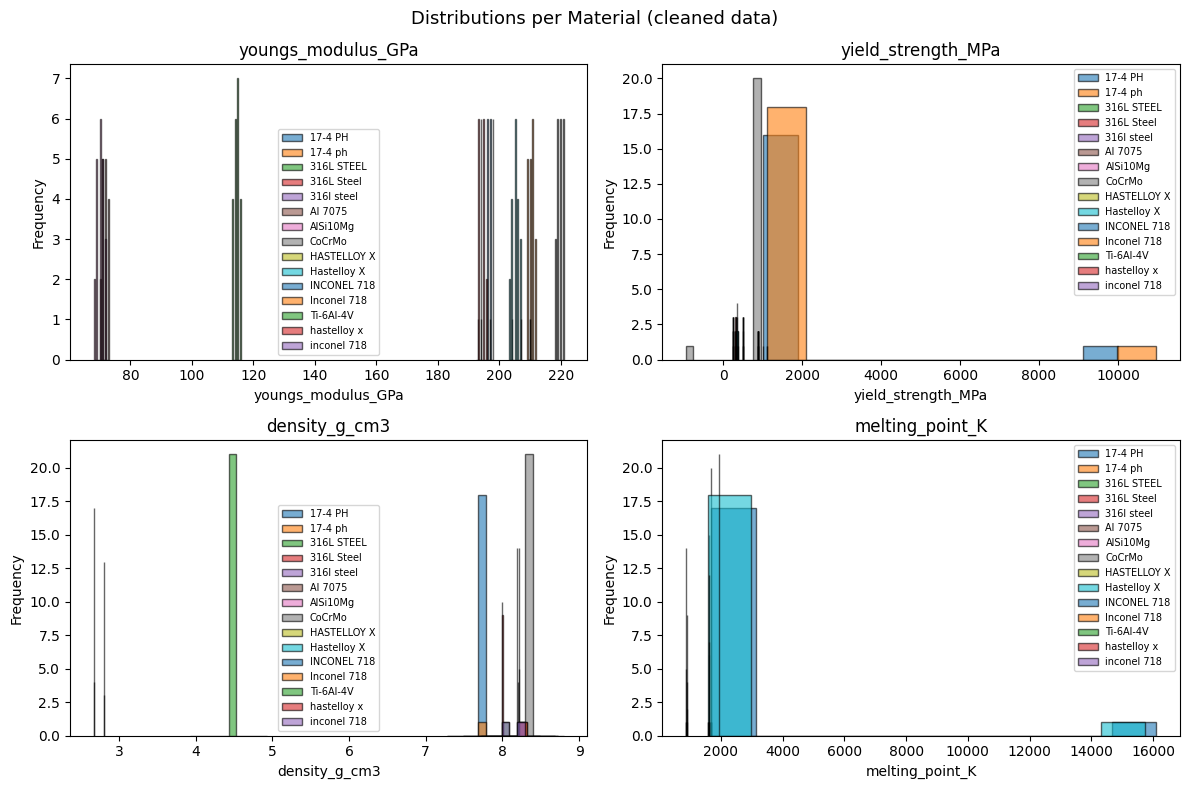

In [15]:
numeric_cols = [
    "youngs_modulus_GPa",
    "yield_strength_MPa",
    "density_g_cm3",
    "melting_point_K",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    for material, grp in df_clean.groupby("material"):
        grp[col].plot(
            kind="hist", bins=10, alpha=0.6, ax=ax, label=material, edgecolor="black"
        )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.legend(fontsize=7)

plt.suptitle("Distributions per Material (cleaned data)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 3 — Curation Strategy

After cleaning, we think about whether the dataset is representative enough for training a model.

| Goal | Question to ask | Example action |
|------|----------------|----------------|
| **Balance** | Is any class (material) over-represented? | Oversample rare materials or undersample frequent ones |
| **Diversity** | Do we cover all real-world scenarios? | Ensure data from multiple labs and conditions |
| **Integrity** | Has the data been altered or corrupted? | Track dataset versions with DVC |

### 3a) Balance — class distribution

**Exercise**  
- Count how many samples exist per material.  
- Plot a bar chart.  
- Which material is most/least represented?  
- How could imbalance bias a model that predicts `youngs_modulus_GPa` from composition?

material
Ti-6Al-4V      21
AlSi10Mg       21
CoCrMo         21
316L Steel     20
Inconel 718    19
Hastelloy X    19
17-4 PH        18
Al 7075        16
316l steel      1
INCONEL 718     1
hastelloy x     1
316L STEEL      1
inconel 718     1
HASTELLOY X     1
17-4 ph         1
Name: count, dtype: int64


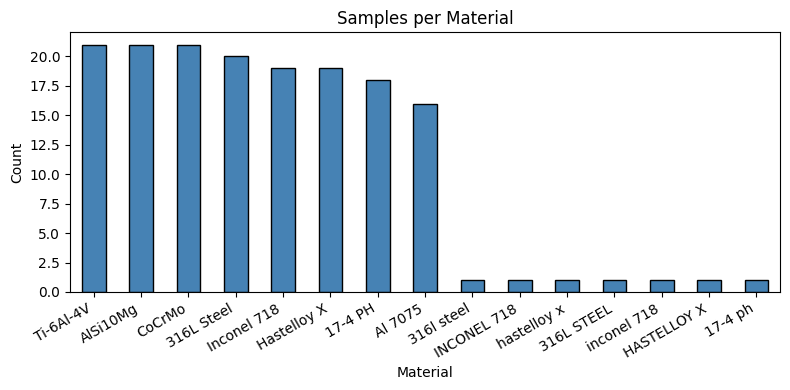

In [16]:
counts = df_clean["material"].value_counts()
print(counts)

counts.plot(kind="bar", figsize=(8, 4), edgecolor="black", color="steelblue")
plt.title("Samples per Material")
plt.xlabel("Material")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 3b) Balance — simple oversampling of rare classes

A basic way to balance classes is **random oversampling**: duplicate rows of under-represented classes until all classes have the same count as the majority class.

**Exercise**  
- Use `DataFrame.sample` with `replace=True` to oversample each minority class to the majority count.  
- Verify with another bar chart.

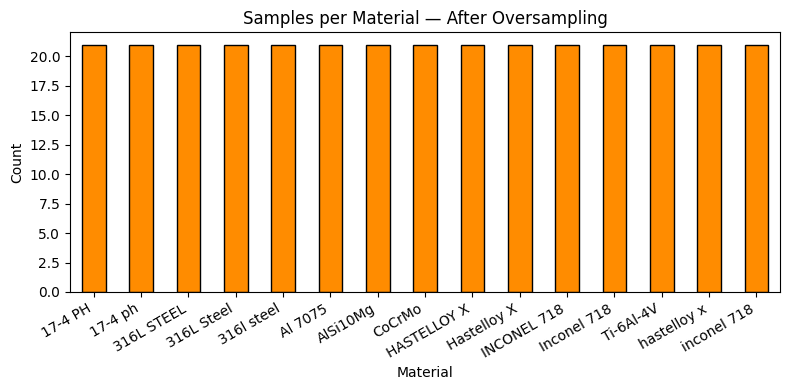

Dataset size before: 162, after balancing: 315


In [17]:
max_count = counts.max()

balanced_frames = []
for material, grp in df_clean.groupby("material"):
    if len(grp) < max_count:
        # Oversample to max_count
        extra = grp.sample(n=max_count - len(grp), replace=True, random_state=42)
        balanced_frames.append(pd.concat([grp, extra]))
    else:
        balanced_frames.append(grp)

df_balanced = pd.concat(balanced_frames).reset_index(drop=True)

df_balanced["material"].value_counts().plot(
    kind="bar", figsize=(8, 4), edgecolor="black", color="darkorange"
)
plt.title("Samples per Material — After Oversampling")
plt.xlabel("Material")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print(f"Dataset size before: {len(df_clean)}, after balancing: {len(df_balanced)}")

> **Note**: Random oversampling creates exact copies. For small datasets this can lead to overfitting.  
> More sophisticated approaches like **SMOTE** generate synthetic samples that interpolate between existing ones.

### 3c) Diversity — source coverage

**Exercise**  
- Make a heatmap (pivot table) of how many samples each `(material, source_lab)` combination has.  
- Are there combinations with zero entries? What does this mean for generalisability?  
- What would you recommend to improve diversity?

source_lab   Lab A  Lab B  Lab C  Lab D  Lab E
material                                      
17-4 PH          4      5      3      3      3
17-4 ph          0      0      0      1      0
316L STEEL       0      0      0      1      0
316L Steel       4      5      5      3      3
316l steel       1      0      0      0      0
Al 7075          3      4      3      3      3
AlSi10Mg         5      4      5      4      3
CoCrMo           5      5      4      3      4
HASTELLOY X      0      0      0      0      1
Hastelloy X      4      5      3      4      3
INCONEL 718      0      1      0      0      0
Inconel 718      5      3      4      4      3
Ti-6Al-4V        6      4      4      4      3
hastelloy x      1      0      0      0      0
inconel 718      0      0      1      0      0


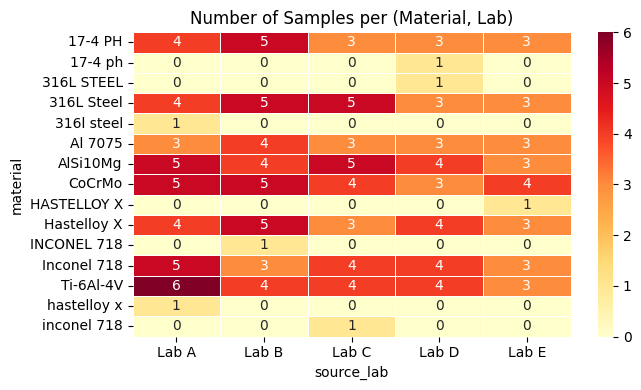

In [18]:
pivot = df_clean.pivot_table(
    index="material", columns="source_lab", aggfunc="size", fill_value=0
)
print(pivot)

plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
plt.title("Number of Samples per (Material, Lab)")
plt.tight_layout()
plt.show()

---
## Summary

| Step | Tool / Technique | What you fixed |
|------|-----------------|----------------|
| Audit — dtypes | `df.dtypes`, `pd.to_numeric` | Strings masquerading as numbers |
| Audit — ranges | `df.describe()`, boolean filters | Negative Young's modulus, sub-zero temperature |
| Audit — correlations | `sns.pairplot`, histograms | Visual outlier (10× modulus) |
| Clean — by hand | String ops, domain knowledge | Whitespace, case, impossible values |
| Clean — IQR | Group-wise IQR filter | Statistical outlier per material |
| Clean — duplicates | `df.duplicated()` | Exact duplicate rows |
| Curate — balance | Random oversampling | Class imbalance |
| Curate — diversity | Pivot heatmap | Missing lab/material combinations |